# Student Performance Analysis and Prediction

### Imported Libraries

In [1]:
# I've imported all Libraries for Data Handling and Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I've imported all sklearn tools here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Task 1 - Data Exploration with Pandas

In [2]:
df = pd.read_csv("students.csv")


##### Question 1: Print first 5 rows

In [3]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


##### Que 2. Print the shape (rows × columns) and the data type of each column using .dtypes. 
 

In [6]:
print("Shape of Dataset: ", df.shape)
print("\n")

# the shape of data is found out df.dtypes
print("Data Types of each Columns: ")
print(df.dtypes)

Shape of Dataset:  (15, 9)


Data Types of each Columns: 
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


##### Question 3 - Print summary statistics

In [ ]:
# using the df.describe() statement, i'm displaying all summary statistic about the data
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

##### Question 4 - Count passed and failed students

In [10]:
# i'm checking here how many student have passed and how many failed
# for this i've used the "passed" column and used the 
# value_counts functions
# 1 --> pass
# 0 --> fail
pass_fail_count = df["passed"].value_counts()
print(pass_fail_count)

passed
1    9
0    6
Name: count, dtype: int64


##### Question 5 - Average score per subject for passing and failing students

In [13]:
# creating an array for each subject that will act like columsn
subject_cols = ["math", "science", "english", "history", "pe"]

# filtering the df with students who have passed(1) and failed(0)
passing_students_avg = df[df["passed"] == 1][subject_cols].mean()
failing_students_avg = df[df["passed"] == 0][subject_cols].mean()

# simply printing the outputs
print("Average subject scores for passing students:")
print(passing_students_avg)
print()

print("Average subject scores for failing students:")
print(failing_students_avg)

Average subject scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average subject scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


##### Question 6 - Student with highest overall average

In [16]:
subject_cols = ["math", "science", "english", "history", "pe"]

# creating a new column called overall average
df["overall_average"] = df[subject_cols].mean(axis=1)

# finding the highest value in overall_average column 
top_student = df.loc[df["overall_average"].idxmax()]

# printing the top student name and his average score
print("Student with the highest overall average:")
print(top_student[["name", "overall_average"]])

Student with the highest overall average:
name               Diana
overall_average     94.0
Name: 3, dtype: object


### Task 2 - Data Visualization with Matplotlib

In [21]:
# adding new column average score as mentioned in the assignment
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)

##### Question 1 - Bar chart of average score per subject

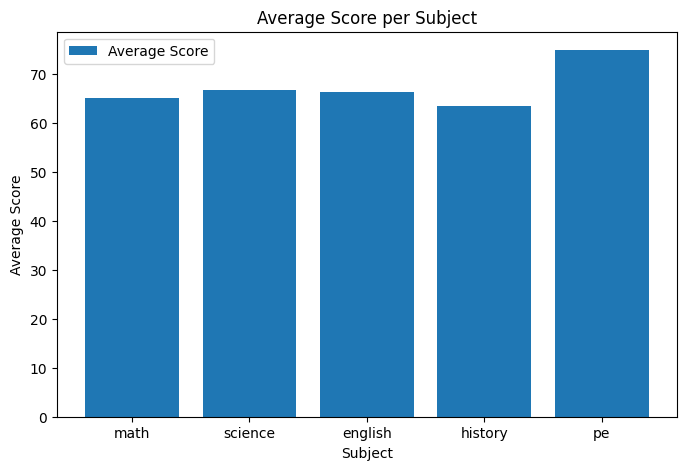

In [22]:
# calculating average score using the mean function
average_scores = df[subject_cols].mean()

# creating bar chart for average subject score
plt.figure(figsize=(8, 5))
plt.bar(average_scores.index, average_scores.values, label="Average Score")

# adding titles, axis labels and legend
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.legend()


plt.savefig("plot1_bar.png")
plt.show()

##### Question 2 - Histogram of math scores

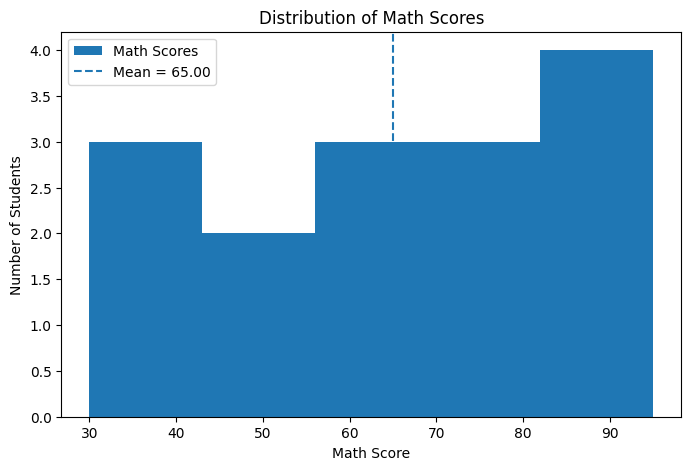

In [ ]:
# calculating the avergae score in maths
math_mean = df["math"].mean()

# creating the plot Area
plt.figure(figsize=(8, 5))

# creating a histogram using maths score
plt.hist(df["math"], bins=5, label="Math Scores")

# draws a vertical line at the avergae math score
plt.axvline(math_mean, linestyle="--", label=f"Mean = {math_mean:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()

# saving the diagram and displaying
plt.savefig("plot2_histogram.png")
plt.show()

##### Question 3 - Scatter plot of study hours vs average score

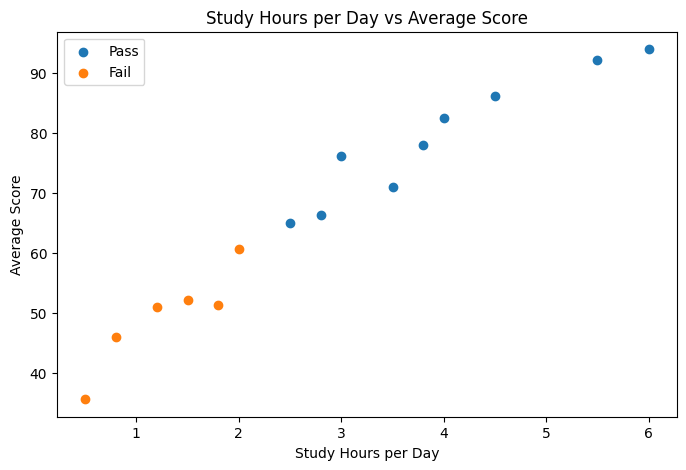

In [ ]:
# creating pass and fail students
pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

# creating the plot area
plt.figure(figsize=(8, 5))

# scatter plot 
plt.scatter(pass_students["study_hours_per_day"], pass_students["avg_score"], label="Pass")
plt.scatter(fail_students["study_hours_per_day"], fail_students["avg_score"], label="Fail")

plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

# saving the plot and displaying it
plt.savefig("plot3_scatter.png")
plt.show()

##### Question 4 - Box plot of attendance for pass and fail students

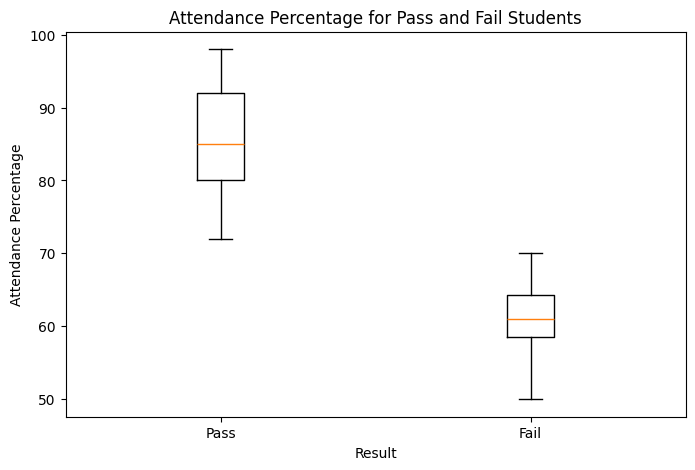

In [ ]:
# creating pass and fail students
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

# creating plot area and starting with boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], tick_labels=["Pass", "Fail"])

# marking the labes
plt.title("Attendance Percentage for Pass and Fail Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")

# 
plt.savefig("plot4_boxplot.png")
plt.show()

##### Question 5 - Line plot of math and science scores for every student

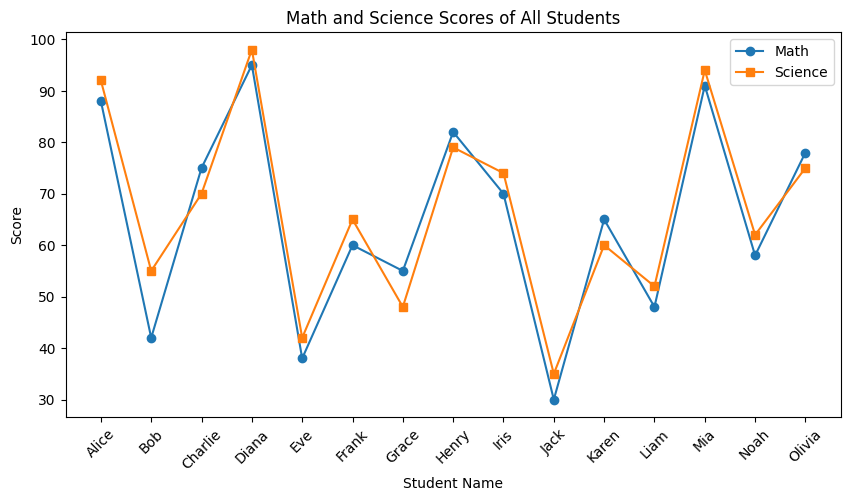

In [ ]:
# creating the plot area
plt.figure(figsize=(10, 5))

# creating plots for maths and sceince
plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="s", label="Science")

# naming the labels
plt.title("Math and Science Scores of All Students")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

# saving the diagram and displaying the plot
plt.savefig("plot5_line.png")
plt.show()